# Neo4j Graph Database Recommendation System Visualization

This notebook demonstrates how to connect to the Neo4j Graph Database, query users, products, and relationships, visualize the graph structure, and get graph-based recommendations.

In [1]:
import os
import sys
import django

# Setup Django environment
sys.path.append(os.path.abspath('..'))
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'recommender_ai_service.settings')

# Configure database connection details for local development outside Docker
os.environ['DB_HOST'] = '127.0.0.1'
os.environ['DB_NAME'] = 'bookstore_ai'
os.environ['NEO4J_URI'] = 'bolt://localhost:7687'
os.environ['NEO4J_USERNAME'] = 'neo4j'
os.environ['NEO4J_PASSWORD'] = 'password123'

# Allow synchronous operations in Jupyter's async context
os.environ['DJANGO_ALLOW_ASYNC_UNSAFE'] = 'true'

django.setup()
print("Django & Neo4j environment setup successfully!")


AI-Service background bootstrap sync will start in 15 seconds...
Django & Neo4j environment setup successfully!


AI-Service background bootstrap sync starting...
ProductNode database already contains records. Skipping bootstrap sync.
Initializing SentenceTransformer encoder...


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


FAISS index successfully rebuilt with 12 items!
FAISS index successfully rebuilt with 12 items!


In [2]:
from app.graph_engine import Neo4jGraphEngine

# Initialize Neo4j graph engine
engine = Neo4jGraphEngine()
if engine.driver:
    with engine.driver.session() as session:
        # Query node counts
        users = session.run("MATCH (u:User) RETURN count(u) AS count").single()["count"]
        products = session.run("MATCH (p:Product) RETURN count(p) AS count").single()["count"]
        
        # Query relationship counts
        buys = session.run("MATCH ()-[r:BUY]->() RETURN count(r) AS count").single()["count"]
        views = session.run("MATCH ()-[r:VIEW]->() RETURN count(r) AS count").single()["count"]
        similars = session.run("MATCH ()-[r:SIMILAR]->() RETURN count(r) AS count").single()["count"]
        
        print("=== Neo4j Graph Database Statistics ===")
        print(f"Users (User):            {users}")
        print(f"Products (Product):      {products}")
        print(f"BUY Relationships:       {buys}")
        print(f"VIEW Relationships:      {views}")
        print(f"SIMILAR Relationships:   {similars}")
else:
    print("Failed to connect to Neo4j database. Check that the service is running.")

Received notification from DBMS server: <GqlStatusObject gql_status='01N42', status_description="One of the relationship types in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing relationship type is: BUY)", position=<SummaryInputPosition line=1, column=13, offset=12>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/', '_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'column': 13, 'offset': 12, 'line': 1}}> for query: 'MATCH ()-[r:BUY]->() RETURN count(r) AS count'


=== Neo4j Graph Database Statistics ===
Users (User):            6
Products (Product):      12
BUY Relationships:       0
VIEW Relationships:      6
SIMILAR Relationships:   132


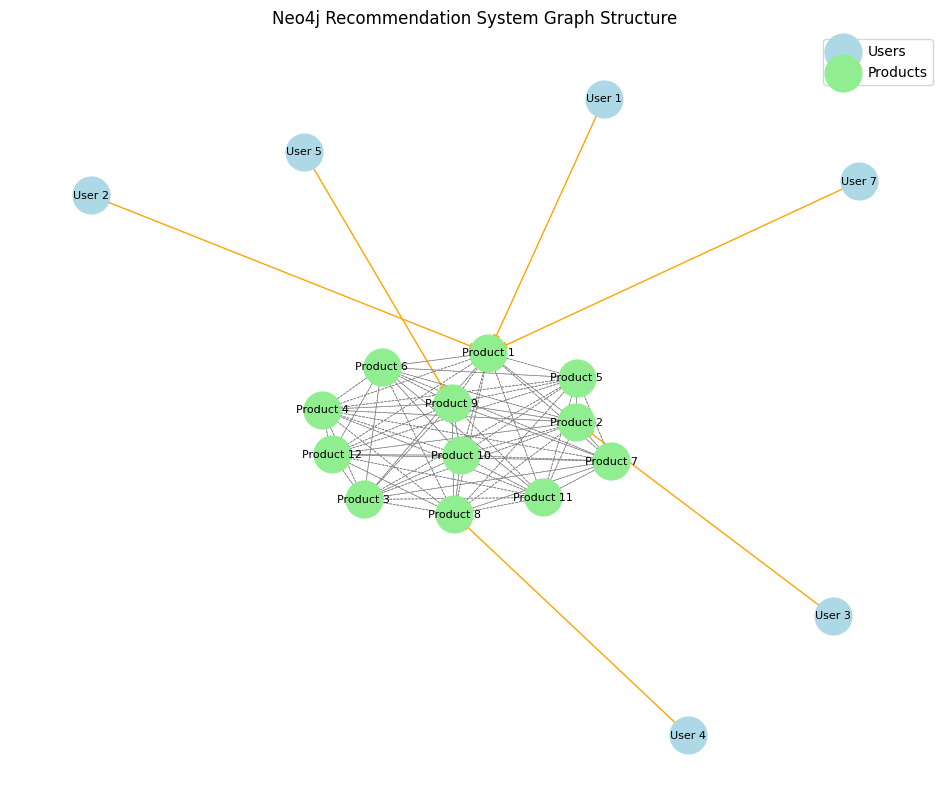

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

if engine.driver:
    G = nx.MultiDiGraph()
    
    with engine.driver.session() as session:
        # Retrieve all nodes and relationships
        result = session.run("MATCH (n)-[r]->(m) RETURN labels(n)[0] as l1, n.id as id1, type(r) as rel, labels(m)[0] as l2, m.id as id2")
        
        for row in result:
            node1 = f"{row['l1']}_{row['id1']}"
            node2 = f"{row['l2']}_{row['id2']}"
            G.add_node(node1, label=row['l1'], id=row['id1'])
            G.add_node(node2, label=row['l2'], id=row['id2'])
            G.add_edge(node1, node2, type=row['rel'])
            
    # Configure plot properties
    plt.figure(figsize=(12, 10))
    pos = nx.spring_layout(G, seed=42, k=0.5)
    
    # Draw nodes by label
    user_nodes = [node for node, attr in G.nodes(data=True) if attr.get('label') == 'User']
    product_nodes = [node for node, attr in G.nodes(data=True) if attr.get('label') == 'Product']
    
    nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, node_color='lightblue', node_size=700, label='Users')
    nx.draw_networkx_nodes(G, pos, nodelist=product_nodes, node_color='lightgreen', node_size=700, label='Products')
    
    # Draw edges by type
    buy_edges = [(u, v) for u, v, k, attr in G.edges(data=True, keys=True) if attr.get('type') == 'BUY']
    view_edges = [(u, v) for u, v, k, attr in G.edges(data=True, keys=True) if attr.get('type') == 'VIEW']
    similar_edges = [(u, v) for u, v, k, attr in G.edges(data=True, keys=True) if attr.get('type') == 'SIMILAR']
    
    nx.draw_networkx_edges(G, pos, edgelist=buy_edges, edge_color='red', width=2, label='BUY', arrows=True)
    nx.draw_networkx_edges(G, pos, edgelist=view_edges, edge_color='orange', width=1, label='VIEW', arrows=True)
    # Draw SIMILAR as dashed thin grey lines to avoid cluttering
    nx.draw_networkx_edges(G, pos, edgelist=similar_edges, edge_color='grey', width=0.5, style='dashed', arrows=False)
    
    # Draw labels
    labels = {node: f"{attr.get('label')} {attr.get('id')}" for node, attr in G.nodes(data=True)}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_family='sans-serif')
    
    plt.title("Neo4j Recommendation System Graph Structure")
    plt.legend(scatterpoints=1)
    plt.axis('off')
    plt.show()
else:
    print("Neo4j driver is not available.")

In [6]:
from pyvis.network import Network
import IPython
import builtins

if engine.driver:
    # Create pyvis network
    net = Network(notebook=True, height='600px', width='100%', bgcolor='#222222', font_color='white', cdn_resources='in_line')
    
    # Configure physics for nice interactive spreading
    net.barnes_hut()
    
    with engine.driver.session() as session:
        # Fetch all User nodes
        users_res = session.run("MATCH (u:User) RETURN u.id as id")
        for row in users_res:
            net.add_node(f"User_{row['id']}", label=f"User {row['id']}", color='#2c3e50', size=25)
            
        # Fetch all Product nodes
        products_res = session.run("MATCH (p:Product) RETURN p.id as id")
        for row in products_res:
            net.add_node(f"Product_{row['id']}", label=f"Product {row['id']}", color='#27ae60', size=20)
            
        # Fetch all relationships
        rels_res = session.run("MATCH (n)-[r]->(m) RETURN labels(n)[0] as l1, n.id as id1, type(r) as rel, labels(m)[0] as l2, m.id as id2")
        for row in rels_res:
            source = f"{row['l1']}_{row['id1']}"
            target = f"{row['l2']}_{row['id2']}"
            rel_type = row['rel']
            
            if rel_type == 'BUY':
                net.add_edge(source, target, title='BUY', color='#e74c3c', width=3)
            elif rel_type == 'VIEW':
                net.add_edge(source, target, title='VIEW', color='#f39c12', width=1.5)
            elif rel_type == 'SIMILAR':
                net.add_edge(source, target, title='SIMILAR', color='#95a5a6', width=0.5, dashes=True)
                
    # Save visual html
    html_path = 'neo4j_graph.html'
    
    # Temporarily monkeypatch builtins.open to force utf-8 encoding for Pyvis template writing on Windows
    orig_open = builtins.open
    try:
        def utf8_open(*args, **kwargs):
            if len(args) > 1 and ('w' in args[1] or 'a' in args[1]):
                kwargs['encoding'] = 'utf-8'
            elif 'mode' in kwargs and ('w' in kwargs['mode'] or 'a' in kwargs['mode']):
                kwargs['encoding'] = 'utf-8'
            return orig_open(*args, **kwargs)
        builtins.open = utf8_open
        
        net.show(html_path)
        print(f"Interactive graph saved to {html_path}")
    finally:
        builtins.open = orig_open
else:
    print("Neo4j driver is not available.")

neo4j_graph.html
Interactive graph saved to neo4j_graph.html


In [7]:
# Test fetching recommendations
user_id = 7
print(f"=== Collaborative Filtering Recommendations for User {user_id} ===")
collab_recs = engine.get_collaborative_recommendations(user_id=user_id, limit=5)
for idx, (pid, score) in enumerate(collab_recs):
    print(f"{idx+1}. Product ID: {pid} (Collaborative Score: {score:.2f})")

print(f"\n=== Similarity Recommendations for User {user_id} ===")
sim_recs = engine.get_similar_recommendations(user_id=user_id, limit=5)
for idx, (pid, score) in enumerate(sim_recs):
    print(f"{idx+1}. Product ID: {pid} (Similarity Score: {score:.4f})")

engine.close()

Received notification from DBMS server: <GqlStatusObject gql_status='01N42', status_description="One of the relationship types in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing relationship type is: BUY)", position=<SummaryInputPosition line=2, column=30, offset=38>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/', '_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'column': 30, 'offset': 38, 'line': 2}}> for query: '\n        MATCH (u1:User {id: $uid})-[:BUY]->(p:Product)<-[:BUY]-(u2:User)-[:BUY]->(rec:Product)\n        WHERE NOT (u1)-[:BUY|VIEW]->(rec) AND rec.id <> p.id\n        RETURN rec.id AS product_id, count(u2) AS score\

=== Collaborative Filtering Recommendations for User 7 ===

=== Similarity Recommendations for User 7 ===


Received notification from DBMS server: <GqlStatusObject gql_status='01N42', status_description="One of the relationship types in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing relationship type is: BUY)", position=<SummaryInputPosition line=2, column=34, offset=42>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/', '_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'column': 34, 'offset': 42, 'line': 2}}> for query: '\n        MATCH (u:User {id: $uid})-[:VIEW|BUY]->(p:Product)-[r:SIMILAR]->(rec:Product)\n        WHERE NOT (u)-[:VIEW|BUY]->(rec)\n        RETURN rec.id AS product_id, sum(r.score) AS score\n        ORDER BY score DE

1. Product ID: 11 (Similarity Score: 0.6000)
2. Product ID: 10 (Similarity Score: 0.6000)
3. Product ID: 9 (Similarity Score: 0.6000)
4. Product ID: 8 (Similarity Score: 0.6000)
5. Product ID: 12 (Similarity Score: 0.6000)
